In [1]:
import os

# Define root path
root_dir = '/kaggle/working/custom_dataset'

# Define categories
categories = ['potato', 'tomato']
subcategories = ['disease', 'healthy']

# Create folders
for category in categories:
    for sub in subcategories:
        path = os.path.join(root_dir, category, sub)
        os.makedirs(path, exist_ok=True)

print("Custom dataset folders created successfully!")

Custom dataset folders created successfully!


In [2]:
import os
import shutil
import random

# Define paths
source_base = '/kaggle/input/potato-crop-disease-and-health-dataset/potato'
target_disease = '/kaggle/working/custom_dataset/potato/disease'
target_healthy = '/kaggle/working/custom_dataset/potato/healthy'

# Disease categories and samples per class
disease_classes = ['common_scab', 'cut', 'dry_rot', 'gangrene', 'violet_root_rot']
samples_per_disease = 500
samples_healthy = 2500

# Create directories
os.makedirs(target_disease, exist_ok=True)
os.makedirs(target_healthy, exist_ok=True)

# Copy disease samples
for disease in disease_classes:
    src_path = os.path.join(source_base, disease)
    images = os.listdir(src_path)
    selected = random.sample(images, samples_per_disease)

    for img in selected:
        shutil.copy(os.path.join(src_path, img), os.path.join(target_disease, f"{disease}_{img}"))

# Copy healthy samples
healthy_path = os.path.join(source_base, 'healthy')
healthy_images = os.listdir(healthy_path)
selected_healthy = random.sample(healthy_images, samples_healthy)

for img in selected_healthy:
    shutil.copy(os.path.join(healthy_path, img), os.path.join(target_healthy, img))

print("Potato dataset subset created successfully.")

Potato dataset subset created successfully.


In [3]:
import os
import shutil
import random

# Source directories
source_base = '/kaggle/input/tomatoes-dataset/content/ieee-mbl-cls/train'
target_disease = '/kaggle/working/custom_dataset/tomato/disease'
target_healthy = '/kaggle/working/custom_dataset/tomato/healthy'

# Create directories
os.makedirs(target_disease, exist_ok=True)
os.makedirs(target_healthy, exist_ok=True)

# Set random seed for reproducibility
random.seed(42)

# --- Disease: Damaged (all) + Old (partial)
# Damaged
damaged_dir = os.path.join(source_base, 'Damaged')
damaged_images = os.listdir(damaged_dir)
for img in damaged_images:
    shutil.copy(os.path.join(damaged_dir, img), os.path.join(target_disease, f'damaged_{img}'))

# Old (partial)
old_dir = os.path.join(source_base, 'Old')
old_images = os.listdir(old_dir)
selected_old = random.sample(old_images, 1551)
for img in selected_old:
    shutil.copy(os.path.join(old_dir, img), os.path.join(target_disease, f'old_{img}'))

# --- Healthy: Ripe (1375) + Unripe (1125)
# Ripe
ripe_dir = os.path.join(source_base, 'Ripe')
ripe_images = os.listdir(ripe_dir)
selected_ripe = random.sample(ripe_images, 1375)
for img in selected_ripe:
    shutil.copy(os.path.join(ripe_dir, img), os.path.join(target_healthy, f'ripe_{img}'))

# Unripe
unripe_dir = os.path.join(source_base, 'Unripe')
unripe_images = os.listdir(unripe_dir)
selected_unripe = random.sample(unripe_images, 1125)
for img in selected_unripe:
    shutil.copy(os.path.join(unripe_dir, img), os.path.join(target_healthy, f'unripe_{img}'))

print("Tomato dataset subset created successfully.")

Tomato dataset subset created successfully.


In [4]:
import shutil

# Zip the folder
shutil.make_archive('/kaggle/working/custom_dataset', 'zip', '/kaggle/working/custom_dataset')

print("Zipping complete. You can now download the zip file.")

Zipping complete. You can now download the zip file.


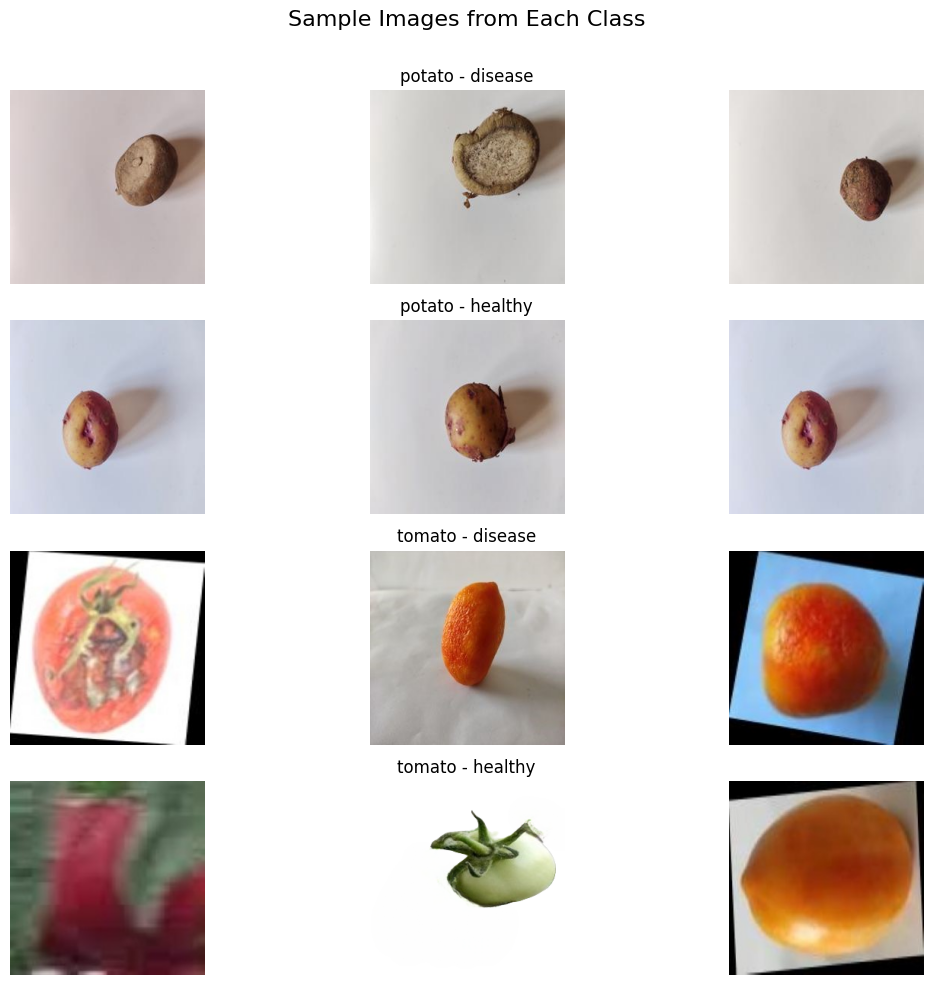

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

# Base directory of your dataset
dest_base = '/kaggle/working/custom_dataset'

# Define categories
categories = [
    'potato/disease',
    'potato/healthy',
    'tomato/disease',
    'tomato/healthy'
]

# Create the plot
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
fig.suptitle('Sample Images from Each Class', fontsize=16)

for i, category in enumerate(categories):
    class_path = os.path.join(dest_base, category)
    image_files = os.listdir(class_path)
    sample_imgs = random.sample(image_files, 3)

    for j in range(3):
        img_path = os.path.join(class_path, sample_imgs[j])
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 1:
            axes[i, j].set_title(category.replace('/', ' - '), fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Make room for the main title
plt.show()


In [7]:
import os

# Base path of custom dataset
dataset_base = '/kaggle/working/custom_dataset'

# Define classes
categories = [
    'potato/disease',
    'potato/healthy',
    'tomato/disease',
    'tomato/healthy'
]

# Count and print
print("Sample count per class:\n")
for category in categories:
    class_path = os.path.join(dataset_base, category)
    count = len(os.listdir(class_path))
    print(f"{category}: {count} images")


Sample count per class:

potato/disease: 2500 images
potato/healthy: 2500 images
tomato/disease: 2500 images
tomato/healthy: 2500 images


In [8]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
original_dataset_dir = '/kaggle/working/custom_dataset'
output_dir = '/kaggle/working/custom_dataset_split'
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')

val_split = 0.2  # 20% for validation

# Iterate over crop type and health status
for crop in os.listdir(original_dataset_dir):
    crop_path = os.path.join(original_dataset_dir, crop)
    
    for condition in os.listdir(crop_path):
        class_path = os.path.join(crop_path, condition)
        images = os.listdir(class_path)

        # Split the images
        train_images, val_images = train_test_split(images, test_size=val_split, random_state=42, shuffle=True)

        # Create destination directories
        train_class_dir = os.path.join(train_dir, crop, condition)
        val_class_dir = os.path.join(val_dir, crop, condition)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        # Copy files
        for img in train_images:
            shutil.copy(os.path.join(class_path, img), os.path.join(train_class_dir, img))
        for img in val_images:
            shutil.copy(os.path.join(class_path, img), os.path.join(val_class_dir, img))

print("✅ Custom dataset successfully split into training and validation sets.")

✅ Custom dataset successfully split into training and validation sets.


In [9]:
import os
import pandas as pd

# Base directories
base_dirs = [
    '/kaggle/working/custom_dataset_split/train',
    '/kaggle/working/custom_dataset_split/val'
]

# Lists to store metadata
filenames, crops, conditions = [], [], []

# Loop through each directory
for base_dir in base_dirs:
    for crop in os.listdir(base_dir):
        crop_path = os.path.join(base_dir, crop)
        if not os.path.isdir(crop_path):
            continue

        for condition in os.listdir(crop_path):
            condition_path = os.path.join(crop_path, condition)
            if not os.path.isdir(condition_path):
                continue

            for file in os.listdir(condition_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    rel_path = os.path.join(os.path.basename(base_dir), crop, condition, file)
                    filenames.append(rel_path)
                    crops.append(crop.lower())
                    conditions.append(condition.lower())

# Create DataFrame
df = pd.DataFrame({
    'filename': filenames,
    'crop': crops,
    'condition': conditions
})

# Save as CSV
df.to_csv('/kaggle/working/custom_metadata.csv', index=False)
print("✅ Metadata CSV created (without split info)")

✅ Metadata CSV created (without split info)


In [10]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode labels
crop_encoder = LabelEncoder()
condition_encoder = LabelEncoder()

df['crop_encoded'] = crop_encoder.fit_transform(df['crop'])
df['condition_encoded'] = condition_encoder.fit_transform(df['condition'])

# One-hot encode
crop_labels = to_categorical(df['crop_encoded'])
condition_labels = to_categorical(df['condition_encoded'])

2025-05-06 17:24:27.468175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746552267.656083      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746552267.710686      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [11]:
# Add individual columns for one-hot encoded labels
crop_classes = pd.DataFrame(crop_labels, columns=[f'crop_{cls}' for cls in crop_encoder.classes_])
condition_classes = pd.DataFrame(condition_labels, columns=[f'condition_{cls}' for cls in condition_encoder.classes_])

df = pd.concat([df, crop_classes, condition_classes], axis=1)


crop_cols = [col for col in df.columns if col.startswith('crop_')]
cond_cols = [col for col in df.columns if col.startswith('condition_')]

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
   rescale=1./255,
    rotation_range=40,  # Increase rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,  # Increase zoom
    horizontal_flip=True,
    vertical_flip=True,  # Add vertical flip for more variability
    brightness_range=[0.7, 1.3],  # Adjust brightness
    channel_shift_range=20.0,  # Random channel shifts
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_df = df[df['filename'].str.startswith('train')]
val_df = df[df['filename'].str.startswith('val')]

crop_cols = crop_classes.columns.tolist()
cond_cols = condition_classes.columns.tolist()

combined_y_cols = crop_cols + cond_cols

train_generator_raw = train_datagen.flow_from_dataframe(
    train_df,
    directory='/kaggle/working/custom_dataset_split',
    x_col='filename',
    y_col=combined_y_cols,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw'
)
val_generator_raw = val_datagen.flow_from_dataframe(
    val_df,
    directory='/kaggle/working/custom_dataset_split',
    x_col='filename',
    y_col=combined_y_cols,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)


Found 8000 validated image filenames.
Found 2000 validated image filenames.


In [13]:
print("Train crop classes:", train_df['crop'].unique())
print("Val crop classes:", val_df['crop'].unique())

Train crop classes: ['potato' 'tomato']
Val crop classes: ['potato' 'tomato']


In [31]:
import tensorflow as tf

def split_generator(generator, crop_dim):
    for x_batch, y_batch in generator:
        crop_labels = y_batch[:, :crop_dim]
        condition_labels = y_batch[:, crop_dim:]
        yield x_batch, (crop_labels, condition_labels)

# Convert generator to tf.data.Dataset
def create_dataset(generator, crop_dim):
    dataset = tf.data.Dataset.from_generator(
        lambda: split_generator(generator, crop_dim),
        output_signature=(
            tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),  # x_batch
            (
                tf.TensorSpec(shape=(None, 2), dtype=tf.float32),  # fruit_labels
                tf.TensorSpec(shape=(None, 2), dtype=tf.float32)   # condition_labels
            )
        )
    )
    return dataset


train_dataset = create_dataset(train_generator_raw, crop_dim=len(crop_cols))
val_dataset = create_dataset(val_generator_raw, crop_dim=len(crop_cols))

In [32]:
print(len(crop_cols))
print(crop_cols)

2
['crop_potato', 'crop_tomato']


In [33]:
from tensorflow.keras import layers, models, Input, Model, regularizers


input_layer = Input(shape=(224, 224, 3))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = layers.BatchNormalization()(x) 
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)  # Increase dense layer size
x = layers.Dropout(0.5)(x)
crop_output = layers.Dense(2, activation='softmax', name='crop')(x)
condition_output = layers.Dense(2, activation='softmax', name='condition')(x)
model = Model(inputs=input_layer, outputs=[crop_output, condition_output])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={
        'crop': 'categorical_crossentropy',
        'condition': 'categorical_crossentropy'
    },
    # loss_weights={'crop': 1.5, 'condition': 1.0},
    metrics={'crop': 'accuracy', 'condition': 'accuracy'}
)

# model.summary()

In [34]:
from tensorflow.keras.callbacks import Callback
import numpy as np

class CyclicLR(Callback):
    def __init__(self, base_lr=1e-5, max_lr=1e-3, step_size=2000, mode='triangular'):
        super().__init__()
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.step_size = step_size
        self.mode = mode
        self.clr_iterations = 0
        self.trn_iterations = 0
        self.history = {}

    def clr(self):
        cycle = np.floor(1 + self.clr_iterations / (2 * self.step_size))
        x = np.abs(self.clr_iterations / self.step_size - 2 * cycle + 1)
        if self.mode == 'triangular':
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x))
        return self.base_lr

    def on_train_begin(self, logs=None):
        logs = logs or {}
        self.clr_iterations = 0
        self.model.optimizer.lr = self.base_lr

    def on_batch_end(self, batch, logs=None):
        self.trn_iterations += 1
        self.clr_iterations += 1
        lr = self.clr()
        self.model.optimizer.lr = lr
        self.history.setdefault('lr', []).append(lr)
        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)

clr = CyclicLR(base_lr=1e-5, max_lr=1e-3, step_size=2000)

In [35]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6
)

In [ ]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=len(train_generator_raw),
    validation_steps=len(val_generator_raw),
    epochs=50,
    verbose=1,  # Print progress for each epoch
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        reduce_lr,
        clr
    ]
)

Epoch 1/50


I0000 00:00:1746552554.940205      94 service.cc:148] XLA service 0x7aa2e4001cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746552554.941023      94 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746552555.493407      94 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/250 ━━━━━━━━━━━━━━━━━━━━ 49:40 12s/step - condition_accuracy: 0.6250 - condition_loss: 0.7019 - crop_accuracy: 0.5000 - crop_loss: 1.0461 - loss: 5.1701

I0000 00:00:1746552561.050098      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 114s 408ms/step - condition_accuracy: 0.7439 - condition_loss: 0.5114 - crop_accuracy: 0.8812 - crop_loss: 0.2910 - loss: 4.0125 - val_condition_accuracy: 0.4850 - val_condition_loss: 0.6963 - val_crop_accuracy: 0.9530 - val_crop_loss: 0.5399 - val_loss: 3.8060 - learning_rate: 1.0000e-04
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 98s 395ms/step - condition_accuracy: 0.8704 - condition_loss: 0.3105 - crop_accuracy: 0.9664 - crop_loss: 0.1105 - loss: 2.8036 - val_condition_accuracy: 0.7865 - val_condition_loss: 0.4620 - val_crop_accuracy: 0.9780 - val_crop_loss: 0.1686 - val_loss: 2.5189 - learning_rate: 1.0000e-04
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 98s 393ms/step - condition_accuracy: 0.8931 - condition_loss: 0.2704 - crop_accuracy: 0.9820 - crop_loss: 0.0583 - loss: 2.0813 - val_condition_accuracy: 0.8820 - val_condition_loss: 0.2496 - val_crop_accuracy: 0.9985 - val_crop_loss: 0.0251 - val_loss: 1.6694 - learning_rate: 1.0000e-04
Epoch 4/50
250/250 ━━━━

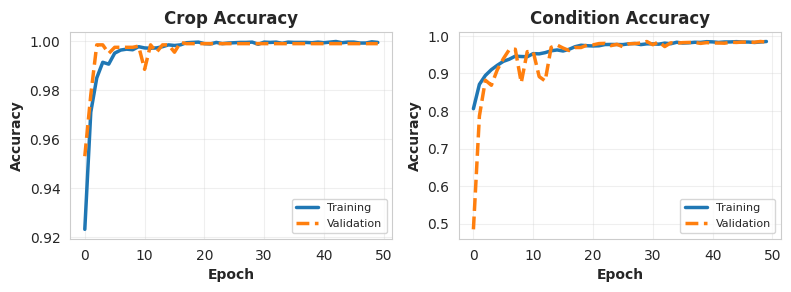

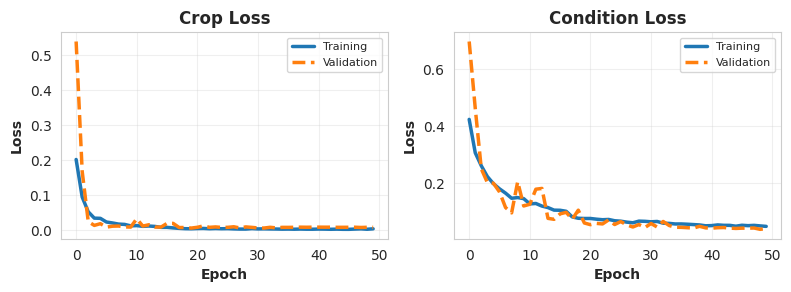

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style for professional look
sns.set_style("whitegrid")


# Create figure with two subplots for accuracy
plt.figure(figsize=(8, 3))  # Compact size for paper

# Plot Fruit Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['crop_accuracy'], label='Training', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_crop_accuracy'], label='Validation', color='#ff7f0e', linewidth=2.5, linestyle='--')
plt.title('Crop Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10, fontweight='bold')
plt.ylabel('Accuracy', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)

# Plot Condition Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['condition_accuracy'], label='Training', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_condition_accuracy'], label='Validation', color='#ff7f0e', linewidth=2.5, linestyle='--')
plt.title('Condition Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10, fontweight='bold')
plt.ylabel('Accuracy', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)

plt.tight_layout(pad=1.0)
plt.savefig('/kaggle/working/accuracy_curves_bold.png', dpi=300, bbox_inches='tight')
plt.show()

# Create figure with two subplots for loss
plt.figure(figsize=(8, 3))  # Compact size for paper

# Plot Fruit Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['crop_loss'], label='Training', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_crop_loss'], label='Validation', color='#ff7f0e', linewidth=2.5, linestyle='--')
plt.title('Crop Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10, fontweight='bold')
plt.ylabel('Loss', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)

# Plot Condition Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['condition_loss'], label='Training', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_condition_loss'], label='Validation', color='#ff7f0e', linewidth=2.5, linestyle='--')
plt.title('Condition Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10, fontweight='bold')
plt.ylabel('Loss', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)

plt.tight_layout(pad=1.0)
plt.savefig('/kaggle/working/loss_curves_bold.png', dpi=300, bbox_inches='tight')
plt.show()

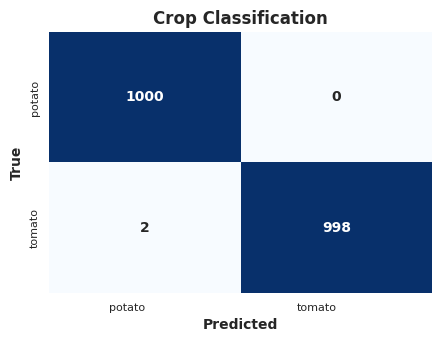

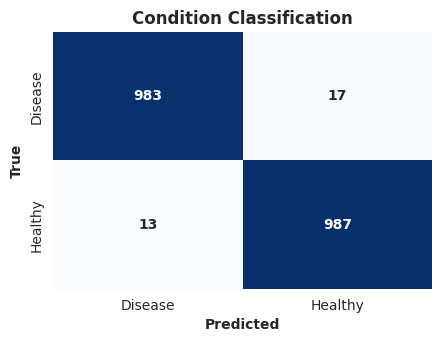

In [41]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Define dict_generator function
def dict_generator(generator, crop_dim):
    for x_batch, y_batch in generator:
        yield x_batch, {
            'crop': y_batch[:, :crop_dim],
            'condition': y_batch[:, crop_dim:]
        }

# Re-create val_gen to ensure fresh iteration
val_generator_raw.reset()  # Reset the Keras generator
val_gen = dict_generator(val_generator_raw, crop_dim=len(crop_cols))

# Collect true and predicted labels
y_true_crop = []
y_true_condition = []
y_pred_crop = []
y_pred_condition = []

# Iterate through val_gen to get predictions
for _ in range(len(val_generator_raw)):
    x_batch, y_batch = next(val_gen)
    predictions = model.predict(x_batch, verbose=0)
    
    # True labels from dict_generator output
    y_true_crop.extend(np.argmax(y_batch['crop'], axis=1))
    y_true_condition.extend(np.argmax(y_batch['condition'], axis=1))
    
    # Predicted labels
    y_pred_crop.extend(np.argmax(predictions[0], axis=1))  # Crop predictions
    y_pred_condition.extend(np.argmax(predictions[1], axis=1))  # Condition predictions

# Convert to numpy arrays
y_true_crop = np.array(y_true_crop)
y_true_condition = np.array(y_true_condition)
y_pred_crop = np.array(y_pred_crop)
y_pred_condition = np.array(y_pred_condition)

# Compute confusion matrices
cm_crop = confusion_matrix(y_true_crop, y_pred_crop)
cm_condition = confusion_matrix(y_true_condition, y_pred_condition)

# Set Seaborn style for professional look
sns.set_style("whitegrid")

# Plot Fruit Confusion Matrix with rotated x-axis labels
plt.figure(figsize=(4.5, 3.5))  # Slightly larger for label spacing
sns.heatmap(cm_crop, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=crop_encoder.classes_, yticklabels=crop_encoder.classes_,
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Crop Classification', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=10, fontweight='bold')
plt.ylabel('True', fontsize=10, fontweight='bold')
plt.xticks(ha='right', fontsize=8)  # Rotate x-axis labels
plt.yticks(fontsize=8)  # Smaller y-axis font size
plt.tight_layout(pad=1.0)
plt.savefig('/kaggle/working/crop_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot Condition Confusion Matrix (unchanged)
plt.figure(figsize=(4.5, 3.5))  # Smaller size for 2x2 matrix
sns.heatmap(cm_condition, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Disease', 'Healthy'], yticklabels=['Disease', 'Healthy'],
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Condition Classification', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=10, fontweight='bold')
plt.ylabel('True', fontsize=10, fontweight='bold')
plt.tight_layout(pad=1.0)
plt.savefig('/kaggle/working/condition_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
import numpy as np
from sklearn.metrics import classification_report
import pandas as pd

# Define dict_generator function
def dict_generator(generator, crop_dim):
    for x_batch, y_batch in generator:
        yield x_batch, {
            'crop': y_batch[:, :crop_dim],
            'condition': y_batch[:, crop_dim:]
        }

# Re-create val_gen to ensure fresh iteration
val_generator_raw.reset()  # Reset the Keras generator
val_gen = dict_generator(val_generator_raw, crop_dim=len(crop_cols))

# Collect true and predicted labels
y_true_crop = []
y_true_condition = []
y_pred_crop = []
y_pred_condition = []

# Iterate through val_gen to get predictions
for _ in range(len(val_generator_raw)):
    x_batch, y_batch = next(val_gen)
    predictions = model.predict(x_batch, verbose=0)
    
    # True labels from dict_generator output
    y_true_crop.extend(np.argmax(y_batch['crop'], axis=1))
    y_true_condition.extend(np.argmax(y_batch['condition'], axis=1))
    
    # Predicted labels
    y_pred_crop.extend(np.argmax(predictions[0], axis=1))  # Fruit predictions
    y_pred_condition.extend(np.argmax(predictions[1], axis=1))  # Condition predictions

# Convert to numpy arrays
y_true_crop = np.array(y_true_crop)
y_true_condition = np.array(y_true_condition)
y_pred_crop = np.array(y_pred_crop)
y_pred_condition = np.array(y_pred_condition)

# Generate classification reports
crop_report = classification_report(y_true_crop, y_pred_crop, target_names=crop_encoder.classes_, output_dict=True)
condition_report = classification_report(y_true_condition, y_pred_condition, target_names=['Disease', 'Healthy'], output_dict=True)

# Convert to DataFrames with custom formatting
crop_df = pd.DataFrame(crop_report).transpose()
crop_df['precision'] = crop_df['precision'].round(2)
crop_df['recall'] = crop_df['recall'].round(2)
crop_df['f1-score'] = crop_df['f1-score'].round(2)
crop_df['support'] = crop_df['support'].astype(int)  # Keep support as integer

condition_df = pd.DataFrame(condition_report).transpose()
condition_df['precision'] = condition_df['precision'].round(2)
condition_df['recall'] = condition_df['recall'].round(2)
condition_df['f1-score'] = condition_df['f1-score'].round(2)
condition_df['support'] = condition_df['support'].astype(int)  # Keep support as integer

# Print Crop classification report
print("Crop Classification Report:")
print(crop_df[['precision', 'recall', 'f1-score', 'support']])

# Print condition classification report
print("\nCondition Classification Report:")
print(condition_df[['precision', 'recall', 'f1-score', 'support']])

# Save reports as Markdown tables for paper
with open('/kaggle/working/crop_classification_report.md', 'w') as f:
    f.write("### Crop Classification Report\n")
    f.write(crop_df[['precision', 'recall', 'f1-score', 'support']].to_markdown(index=True, floatfmt=".2f"))

with open('/kaggle/working/condition_classification_report.md', 'w') as f:
    f.write("### Condition Classification Report\n")
    f.write(condition_df[['precision', 'recall', 'f1-score', 'support']].to_markdown(index=True, floatfmt=".2f"))

# LaTeX table for fruit classification
crop_latex = crop_df[['precision', 'recall', 'f1-score', 'support']].to_latex(
    index=True, caption="Crop Classification Metrics", label="tab:crop_metrics", float_format="%.2f"
)
with open('/kaggle/working/crop_classification_report.tex', 'w') as f:
    f.write(crop_latex)

# LaTeX table for condition classification
condition_latex = condition_df[['precision', 'recall', 'f1-score', 'support']].to_latex(
    index=True, caption="Condition Classification Metrics", label="tab:condition_metrics", float_format="%.2f"
)
with open('/kaggle/working/condition_classification_report.tex', 'w') as f:
    f.write(condition_latex)

Crop Classification Report:
              precision  recall  f1-score  support
potato              1.0     1.0       1.0     1000
tomato              1.0     1.0       1.0     1000
accuracy            1.0     1.0       1.0        0
macro avg           1.0     1.0       1.0     2000
weighted avg        1.0     1.0       1.0     2000

Condition Classification Report:
              precision  recall  f1-score  support
Disease            0.99    0.98      0.98     1000
Healthy            0.98    0.99      0.99     1000
accuracy           0.98    0.98      0.98        0
macro avg          0.99    0.98      0.98     2000
weighted avg       0.99    0.98      0.98     2000


In [45]:
model.summary()
print([layer.name for layer in model.layers if 'conv2d' in layer.name.lower()])

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 224, 224, 32)   │            896 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_12    │ (None, 224, 224, 32)   │            128 │ conv2d_12[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_12          │ (None, 112, 112, 32)   │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 112, 112, 64)   │         18,496 │ max_pooling2d_12[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 112, 112, 64)   │            256 │ conv2d_13[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_13          │ (None, 56, 56, 64)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 56, 56, 128)    │         73,856 │ max_pooling2d_13[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 56, 56, 128)    │            512 │ conv2d_14[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_14          │ (None, 28, 28, 128)    │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 28, 28, 256)    │        295,168 │ max_pooling2d_14[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_15    │ (None, 28, 28, 256)    │          1,024 │ conv2d_15[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_15          │ (None, 14, 14, 256)    │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 256)            │              0 │ max_pooling2d_15[0][0] │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)      

 Total params: 1,569,998 (5.99 MB)

 Trainable params: 523,012 (2.00 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 1,046,026 (3.99 MB)

['conv2d_12', 'conv2d_13', 'conv2d_14', 'conv2d_15']


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to initialize model
def initialize_model(model, input_shape=(224, 224, 3)):
    try:
        # Explicitly build the model
        model.build((None, *input_shape))
        print("Model built successfully.")
        
        # Perform a dummy forward pass
        dummy_input = np.random.rand(1, *input_shape).astype(np.float32)
        outputs = model.predict(dummy_input)
        print("Dummy prediction output shapes:", [output.shape for output in outputs])  # Expected: [(1, 4), (1, 2)]
        print("Model initialized successfully.")
    except Exception as e:
        print(f"Error during model initialization: {e}")
        raise e

# Function to get Grad-CAM heatmap for a specific output
def direct_gradcam_heatmap(model, img_array, last_conv_layer_name, output_name, pred_index=None):
    try:
        # Get the last convolutional layer
        conv_layer = model.get_layer(last_conv_layer_name)
        print(f"Found layer: {last_conv_layer_name}")
        
        # Create a sub-model from input to conv_layer and output
        grad_model = tf.keras.Model(
            inputs=model.inputs,
            outputs=[conv_layer.output, model.get_layer(output_name).output]
        )
        print(f"Grad-CAM sub-model created for output: {output_name}")
        
        # Convert img_array to tf.Tensor
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        print(f"Image converted to tf.Tensor with shape: {img_tensor.shape}")
        
        # Compute gradients
        with tf.GradientTape() as tape:
            tape.watch(img_tensor)
            conv_outputs, preds = grad_model(img_tensor)
            if pred_index is None:
                pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]
        
        grads = tape.gradient(class_channel, conv_outputs)
        if grads is None:
            raise ValueError(f"Gradients are None for {output_name}. Check model connectivity.")
        
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        print(f"Pooled gradients shape: {pooled_grads.shape}")
        
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        
        return heatmap.numpy(), pred_index
    except Exception as e:
        print(f"Error in direct Grad-CAM for {output_name}: {e}")
        raise e

# Function to display and save original image and Grad-CAM heatmaps
def display_gradcam(img_path, heatmap_crop, heatmap_condition, crop_class, condition_class, alpha=0.4):
    # Load original image
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not load image at {img_path}")
    img = cv2.resize(img, (224, 224))
    
    # Create Grad-CAM heatmaps
    heatmap_crop = cv2.resize(heatmap_crop, (224, 224))
    heatmap_crop = np.uint8(255 * heatmap_crop)
    heatmap_crop = cv2.applyColorMap(heatmap_crop, cv2.COLORMAP_JET)
    superimposed_crop = heatmap_crop * alpha + img
    superimposed_crop = np.clip(superimposed_crop, 0, 255).astype(np.uint8)
    
    heatmap_condition = cv2.resize(heatmap_condition, (224, 224))
    heatmap_condition = np.uint8(255 * heatmap_condition)
    heatmap_condition = cv2.applyColorMap(heatmap_condition, cv2.COLORMAP_JET)
    superimposed_condition = heatmap_condition * alpha + img
    superimposed_condition = np.clip(superimposed_condition, 0, 255).astype(np.uint8)
    
    # Display images
    plt.figure(figsize=(12, 4), dpi=300)
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    # Fruit Grad-CAM
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(superimposed_crop, cv2.COLOR_BGR2RGB))
    plt.title(f'Crop: {crop_class}', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    # Condition Grad-CAM
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(superimposed_condition, cv2.COLOR_BGR2RGB))
    plt.title(f'Condition: {condition_class}', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    # Save figure
    plt.tight_layout(pad=1.0)
    plt.savefig('/kaggle/working/gradcam_two_headed_apple_bad.png', dpi=300, bbox_inches='tight')
    plt.show()

# Example usage
try:
    # Print TensorFlow version
    print(f"TensorFlow version: {tf.__version__}")

    # Print model summary and layer names
    print("Model summary:")
    model.summary()
    print("Layer names:", [layer.name for layer in model.layers])

    # Initialize model
    initialize_model(model)

    # Load and preprocess image
    img_path = '/kaggle/working/custom_dataset/tomato/disease/damaged_d (1).jpg'
    img_array = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img_array)
    img_array = img_array / 255.0  # Rescale as per your preprocessing
    img_array = np.expand_dims(img_array, axis=0)
    print("Image array shape:", img_array.shape, "Min:", img_array.min(), "Max:", img_array.max())

    # Use the last convolutional layer
    last_conv_layer_name = 'conv2d_15'  # Confirmed from model summary
    print(f"Using last convolutional layer: {last_conv_layer_name}")

    # Generate Grad-CAM heatmaps
    heatmap_crop, crop_pred_index = direct_gradcam_heatmap(model, img_array, last_conv_layer_name, output_name='crop')
    heatmap_condition, condition_pred_index = direct_gradcam_heatmap(model, img_array, last_conv_layer_name, output_name='condition')

    # Class names
    crop_classes = crop_encoder.classes_  # e.g., ['apple', 'banana', 'guava', 'orange']
    condition_classes = ['Disease', 'Healthy']  # Adjust if different
    crop_class = crop_classes[crop_pred_index]
    condition_class = condition_classes[condition_pred_index]
    print(f"Predicted crop class: {crop_class}")
    print(f"Predicted condition class: {condition_class}")

    # Display and save Grad-CAM
    display_gradcam(img_path, heatmap_crop, heatmap_condition, crop_class, condition_class)

except Exception as e:
    print(f"Error during Grad-CAM: {e}")